# 05.01 - ML Fundamentals & Problem Formulation

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Machine learning is the science of getting computers to learn patterns from data, then make predictions on new data they have never seen. Instead of writing rules by hand, we show the computer examples and let it discover the rules.

**The core loop:** Data → Model → Train → Evaluate → Deploy

## 2. Why Does This Matter?

Every recommendation system, spam filter, self-driving car, and medical diagnosis tool runs on ML. Understanding the fundamentals lets you build these systems, evaluate whether they work, and know when ML is the wrong tool.

## 3. Prerequisites

- Phase 01: Python (NumPy, pandas, matplotlib)
- Phase 02: Mathematics (linear algebra, calculus basics)
- Phase 03: Statistics (distributions, hypothesis testing)

## 4. Learning Objectives

By the end of this unit, you should be able to:
- Distinguish supervised, unsupervised, and reinforcement learning
- Classify problems as classification or regression
- Walk through the complete ML pipeline from data to deployment
- Identify when ML is appropriate and when it is not
- Formulate a real problem as an ML task

## 5. Mental Model

Think of ML as **automated pattern recognition**:
- You have historical data (inputs → outputs)
- The model learns a mapping function f(inputs) → outputs
- You use f to predict outputs for new inputs

The model does not "understand" — it finds statistical patterns that generalize.

In [1]:
# Import everything we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")

Libraries loaded successfully.
NumPy version: 2.5.2
pandas version: 3.0.5


## 6. The Three Types of Learning

| Type | Input | Output | Example |
|------|-------|--------|----------|
| **Supervised** | Labeled data (X, y) | Predictions | Spam detection, house prices |
| **Unsupervised** | Unlabeled data (X) | Structure | Customer clustering, anomaly detection |
| **Reinforcement** | Rewards/penalties | Actions | Game AI, robotics |

We focus on **supervised learning** in this curriculum because it is the most widely used and the foundation for everything else.

## 7. Classification vs Regression

Both are supervised learning, but the output differs:

- **Classification**: Predict a discrete category (spam/not spam, cat/dog/bird)
- **Regression**: Predict a continuous number (house price, temperature, salary)

Let us see the difference with real examples:

In [2]:
# CLASSIFICATION: Predict whether a tumor is malignant or benign
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
X_class = pd.DataFrame(bc.data, columns=bc.feature_names)
y_class = pd.Series(bc.target, name="diagnosis")

print("=== CLASSIFICATION EXAMPLE ===")
print(f"Task: Predict if tumor is malignant (0) or benign (1)")
print(f"Features: {X_class.shape[1]} measurements (radius, texture, area, etc.)")
print(f"Samples: {X_class.shape[0]}")
print(f"Class distribution:\n{y_class.value_counts().rename({0: 'malignant', 1: 'benign'})}\n")
print(X_class.head(3).to_string())

=== CLASSIFICATION EXAMPLE ===
Task: Predict if tumor is malignant (0) or benign (1)
Features: 30 measurements (radius, texture, area, etc.)
Samples: 569
Class distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter  worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension
0        17.99         10.38           122.8     1001.0          0.11840           0.27760          0.3001              0.14710         0.2419                 0.07871        1.0950         0.9053            8.589      153.40          0.00

In [3]:
# REGRESSION: Predict house price from features
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
y_reg = pd.Series(housing.target * 100000, name="price_usd")  # Scale to dollars

print("=== REGRESSION EXAMPLE ===")
print(f"Task: Predict house price in USD")
print(f"Features: {X_reg.shape[1]} (median income, house age, avg rooms, etc.)")
print(f"Samples: {X_reg.shape[0]}")
print(f"Price range: ${y_reg.min():,.0f} - ${y_reg.max():,.0f}")
print(f"Mean price: ${y_reg.mean():,.0f}\n")
print(X_reg.head(3).to_string())

=== REGRESSION EXAMPLE ===
Task: Predict house price in USD
Features: 8 (median income, house age, avg rooms, etc.)
Samples: 20640
Price range: $14,999 - $500,001
Mean price: $206,856

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24


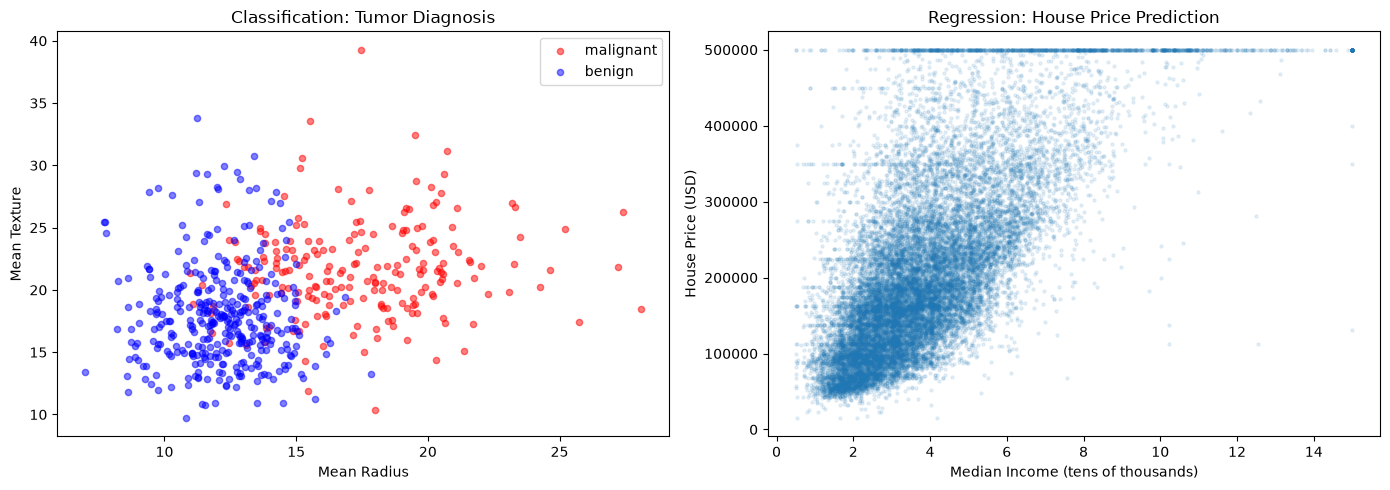

Left: classification (discrete classes). Right: regression (continuous values).


In [4]:
# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification: scatter plot of two features colored by class
ax = axes[0]
for label, color, name in [(0, 'red', 'malignant'), (1, 'blue', 'benign')]:
    mask = y_class == label
    ax.scatter(X_class.loc[mask, 'mean radius'], X_class.loc[mask, 'mean texture'],
              c=color, alpha=0.5, label=name, s=20)
ax.set_xlabel('Mean Radius')
ax.set_ylabel('Mean Texture')
ax.set_title('Classification: Tumor Diagnosis')
ax.legend()

# Regression: scatter plot of one feature vs target
ax = axes[1]
ax.scatter(X_reg['MedInc'], y_reg, alpha=0.1, s=5)
ax.set_xlabel('Median Income (tens of thousands)')
ax.set_ylabel('House Price (USD)')
ax.set_title('Regression: House Price Prediction')

plt.tight_layout()
plt.savefig('classification_vs_regression.png', dpi=100, bbox_inches='tight')
plt.show()
print("Left: classification (discrete classes). Right: regression (continuous values).")

## 8. The ML Pipeline

Every ML project follows this pipeline:

```
1. Problem Formulation  →  What are we predicting? Why?
2. Data Collection        →  Where does data come from?
3. Exploratory Analysis   →  What patterns exist?
4. Data Preprocessing     →  Clean, encode, split
5. Feature Engineering    →  Create useful features
6. Model Selection        →  Which algorithm?
7. Training               →  Fit the model
8. Evaluation             →  How well does it work?
9. Tuning                 →  Optimize hyperparameters
10. Deployment            →  Put it in production
11. Monitoring            →  Track performance over time
```

Let us walk through each step with a concrete example.

In [5]:
# STEP 1: Problem Formulation
print("Problem: Predict whether a Titanic passenger survived")
print("Input: Age, gender, class, fare, etc.")
print("Output: Survived (0) or Died (1)")
print("Type: Binary classification\n")

# STEP 2: Data Collection (use seaborn's Titanic dataset)
import seaborn as sns
titanic = sns.load_dataset('titanic')
print(f"Data loaded: {titanic.shape[0]} passengers, {titanic.shape[1]} columns")
print(f"Columns: {list(titanic.columns)}")
print(f"\nFirst 5 rows:")
titanic.head()

Problem: Predict whether a Titanic passenger survived
Input: Age, gender, class, fare, etc.
Output: Survived (0) or Died (1)
Type: Binary classification



Data loaded: 891 passengers, 15 columns
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# STEP 3: Exploratory Data Analysis (EDA)
print("=== Survival by Gender ===")
print(titanic.groupby('sex')['survived'].mean())
print("\n=== Survival by Class ===")
print(titanic.groupby('class')['survived'].mean())
print("\n=== Missing Values ===")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])

=== Survival by Gender ===
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

=== Survival by Class ===
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

=== Missing Values ===
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


In [7]:
# STEP 4: Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Select features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = titanic[features + ['survived']].dropna()

# Encode categorical variables
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['embarked'] = LabelEncoder().fit_transform(df['embarked'].astype(str))

titanic_features = df.drop('survived', axis=1)
titanic_target = df['survived']

# Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    titanic_features, titanic_target, test_size=0.2, random_state=42, stratify=titanic_target
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Survival rate (train): {y_train.mean():.3f}")
print(f"Survival rate (test):  {y_test.mean():.3f}")

Training set: 569 samples
Test set:     143 samples
Survival rate (train): 0.404
Survival rate (test):  0.406


In [8]:
# STEP 5: Feature Engineering (simple example)
# Create a new feature: family_size
# (We will cover this in depth in notebook 05.13)
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
X_train_fe['family_size'] = X_train_fe['sibsp'] + X_train_fe['parch'] + 1
X_test_fe['family_size'] = X_test_fe['sibsp'] + X_test_fe['parch'] + 1

print("Added feature: family_size = sibsp + parch + 1")
print(f"Training features: {list(X_train_fe.columns)}")

Added feature: family_size = sibsp + parch + 1
Training features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size']


In [9]:
# STEP 6 & 7: Model Selection and Training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train two different models
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_fe, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_fe, y_train)

print("Models trained:")
print(f"  Logistic Regression: {lr.__class__.__name__}")
print(f"  Random Forest:       {rf.__class__.__name__}")

Models trained:
  Logistic Regression: LogisticRegression
  Random Forest:       RandomForestClassifier


In [10]:
# STEP 8: Evaluation
for name, model in [("Logistic Regression", lr), ("Random Forest", rf)]:
    y_pred = model.predict(X_test_fe)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Report:\n{classification_report(y_test, y_pred, target_names=['Died', 'Survived'])}")


Logistic Regression:
  Accuracy: 0.7902
  Report:
              precision    recall  f1-score   support

        Died       0.82      0.84      0.83        85
    Survived       0.75      0.72      0.74        58

    accuracy                           0.79       143
   macro avg       0.78      0.78      0.78       143
weighted avg       0.79      0.79      0.79       143


Random Forest:
  Accuracy: 0.7692
  Report:
              precision    recall  f1-score   support

        Died       0.82      0.78      0.80        85
    Survived       0.70      0.76      0.73        58

    accuracy                           0.77       143
   macro avg       0.76      0.77      0.76       143
weighted avg       0.77      0.77      0.77       143



## 9. When NOT to Use ML

ML is not always the right tool. Avoid ML when:

| Situation | Why ML Fails | Better Approach |
|-----------|-------------|------------------|
| Simple rules work | "If age > 65, send reminder" | Hard-coded logic |
| Too little data | <50 samples per class | Statistical methods |
| No pattern exists | Random noise | Random guessing |
| Interpretability required | Courts, medical decisions | Decision trees, linear models |
| Real-time critical | <1ms latency required | Lookup tables |
| Cost of error is high | Self-driving, medical | Human-in-the-loop + ML |

**The #1 mistake beginners make: using ML when a simple rule would work.**

In [11]:
# Example: ML vs Simple Rule
# Task: Predict if a student passes based on study hours
np.random.seed(42)
n_students = 100
study_hours = np.random.uniform(0, 10, n_students)
pass_exam = (study_hours > 5).astype(int)  # Simple rule: study > 5 hours → pass

# Add some noise (students who studied but failed, and vice versa)
noise_idx = np.random.choice(n_students, 15, replace=False)
pass_exam[noise_idx] = 1 - pass_exam[noise_idx]

# Simple rule accuracy
rule_pred = (study_hours > 5).astype(int)
rule_acc = (rule_pred == pass_exam).mean()

# ML accuracy (logistic regression)
from sklearn.linear_model import LogisticRegression
ml_model = LogisticRegression(random_state=42)
ml_model.fit(study_hours.reshape(-1, 1), pass_exam)
ml_pred = ml_model.predict(study_hours.reshape(-1, 1))
ml_acc = (ml_pred == pass_exam).mean()

print(f"Simple Rule (>5 hours): {rule_acc:.2%} accuracy")
print(f"Logistic Regression:     {ml_acc:.2%} accuracy")
print(f"\nIn this case, the simple rule works just as well!")
print("ML adds value when the relationship is complex and multi-dimensional.")

Simple Rule (>5 hours): 85.00% accuracy
Logistic Regression:     84.00% accuracy

In this case, the simple rule works just as well!
ML adds value when the relationship is complex and multi-dimensional.


## 10. Key Terminology

| Term | Definition | Example |
|------|-----------|----------|
| **Feature (X)** | Input variable | Age, income, score |
| **Label (y)** | Output variable (what we predict) | Pass/fail, price |
| **Training set** | Data used to learn the model | 80% of data |
| **Test set** | Data held out for evaluation | 20% of data |
| **Model** | The learned mapping function f(X) → y | Linear regression |
| **Hyperparameter** | Setting we choose before training | Learning rate, n_estimators |
| **Parameter** | Value learned from data | Weights, biases |
| **Overfitting** | Model memorizes training data, fails on new data | High train acc, low test acc |
| **Underfitting** | Model is too simple to capture patterns | Low train acc, low test acc |
| **Bias** | Error from wrong assumptions | Underfitting |
| **Variance** | Error from sensitivity to training data | Overfitting |

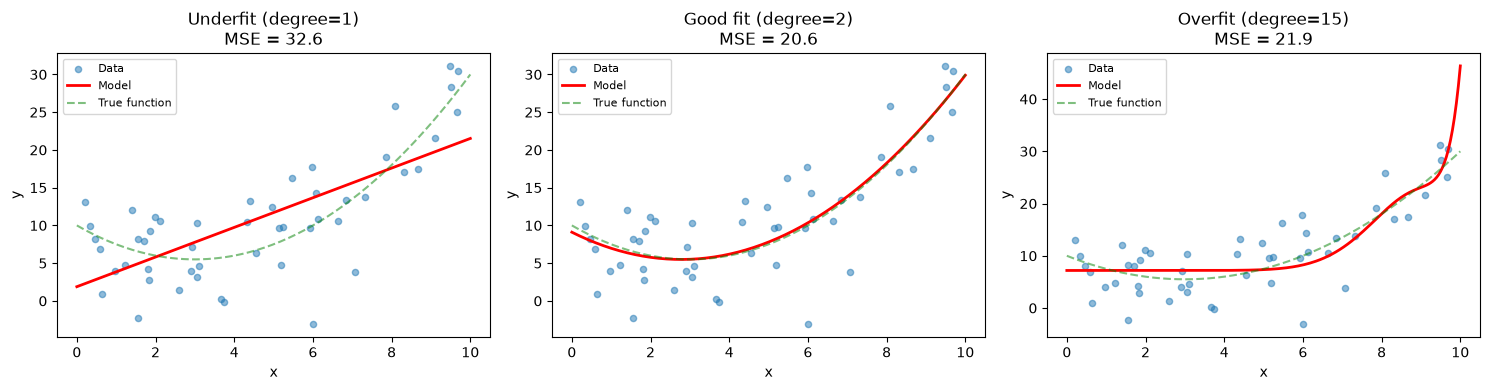

Left: too simple (high bias). Middle: just right. Right: too complex (high variance).


In [12]:
# Visualize Overfitting vs Underfitting
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate noisy quadratic data
np.random.seed(42)
x = np.sort(np.random.uniform(0, 10, 50))
y_true = 0.5 * x**2 - 3 * x + 10
y = y_true + np.random.normal(0, 5, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, degree, title in zip(axes, [1, 2, 15], ["Underfit (degree=1)", "Good fit (degree=2)", "Overfit (degree=15)"]):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    # Training error
    train_mse = ((y - y_pred)**2).mean()
    
    ax.scatter(x, y, s=20, alpha=0.5, label="Data")
    x_plot = np.linspace(0, 10, 200)
    X_plot = poly.transform(x_plot.reshape(-1, 1))
    ax.plot(x_plot, model.predict(X_plot), 'r-', linewidth=2, label="Model")
    ax.plot(x_plot, 0.5*x_plot**2 - 3*x_plot + 10, 'g--', alpha=0.5, label="True function")
    ax.set_title(f"{title}\nMSE = {train_mse:.1f}")
    ax.legend(fontsize=8)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.savefig('overfitting_underfitting.png', dpi=100, bbox_inches='tight')
plt.show()
print("Left: too simple (high bias). Middle: just right. Right: too complex (high variance).")

## 11. Model Complexity & the Bias-Variance Tradeoff

This is the most important concept in ML:

- **Bias**: Error from overly simple assumptions. High bias → underfitting.
- **Variance**: Error from being too sensitive to training data. High variance → overfitting.
- **Total Error = Bias² + Variance + Irreducible Noise**

The goal is to find the sweet spot: low bias AND low variance.

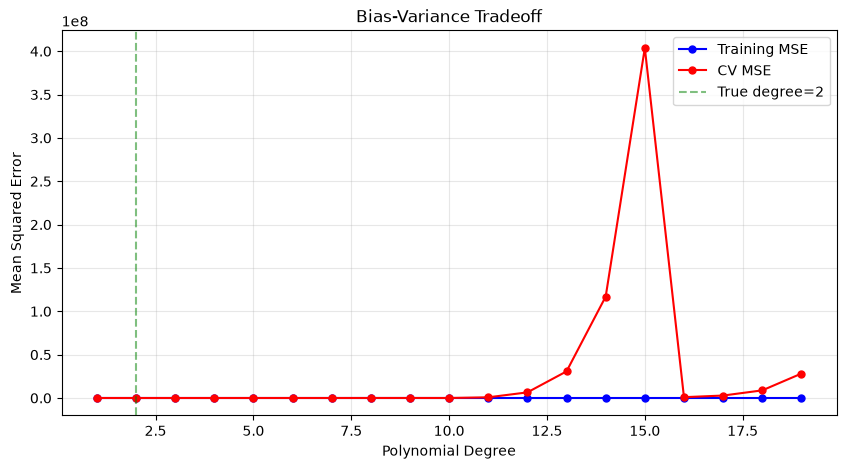

Best CV MSE at degree 2
Training MSE decreases with complexity (overfitting).
CV MSE has a U-shape (sweet spot at degree 2).


In [13]:
# Demonstrate bias-variance tradeoff with polynomial degrees
from sklearn.model_selection import cross_val_score

degrees = range(1, 20)
train_scores = []
cv_scores = []

for d in degrees:
    poly = PolynomialFeatures(d)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    model = LinearRegression()
    
    # Training score (negative MSE, so negate)
    model.fit(X_poly, y)
    train_pred = model.predict(X_poly)
    train_mse = ((y - train_pred)**2).mean()
    train_scores.append(train_mse)
    
    # Cross-validation score
    cv_mse = -cross_val_score(model, X_poly, y, cv=5, scoring='neg_mean_squared_error').mean()
    cv_scores.append(cv_mse)

plt.figure(figsize=(10, 5))
plt.plot(list(degrees), train_scores, 'b-o', label='Training MSE', markersize=5)
plt.plot(list(degrees), cv_scores, 'r-o', label='CV MSE', markersize=5)
plt.axvline(x=2, color='green', linestyle='--', alpha=0.5, label='True degree=2')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('bias_variance_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Best CV MSE at degree {list(degrees)[np.argmin(cv_scores)]}")
print(f"Training MSE decreases with complexity (overfitting).")
print(f"CV MSE has a U-shape (sweet spot at degree 2).")

## 12. Common Mistakes

1. **Testing on training data** — always split first
2. **Data leakage** — using information from the test set in preprocessing
3. **Ignoring class imbalance** — 99% accuracy means nothing if 99% of samples are one class
4. **Not establishing a baseline** — what would a random guess achieve?
5. **Optimizing the wrong metric** — accuracy vs precision vs recall depends on the problem

In [14]:
# Common Mistake #1: Testing on Training Data
print("=== MISTAKE: Testing on Training Data ===")

# Fit on ALL data (wrong!)
model_wrong = LogisticRegression(max_iter=1000, random_state=42)
model_wrong.fit(X_train_fe, y_train)
train_acc_wrong = model_wrong.score(X_train_fe, y_train)  # Test on training!
test_acc_wrong = model_wrong.score(X_test_fe, y_test)

print(f"Train accuracy (testing on training): {train_acc_wrong:.4f}")
print(f"Test accuracy (testing on test):      {test_acc_wrong:.4f}")
print(f"Gap: {train_acc_wrong - test_acc_wrong:.4f} (inflated!)\n")

# Correct approach: fit on train, evaluate on test
model_correct = LogisticRegression(max_iter=1000, random_state=42)
model_correct.fit(X_train_fe, y_train)
train_acc_correct = model_correct.score(X_train_fe, y_train)
test_acc_correct = model_correct.score(X_test_fe, y_test)

print(f"Correct train accuracy: {train_acc_correct:.4f}")
print(f"Correct test accuracy:  {test_acc_correct:.4f}")
print(f"Gap: {train_acc_correct - test_acc_correct:.4f} (honest estimate)")

=== MISTAKE: Testing on Training Data ===
Train accuracy (testing on training): 0.7996
Test accuracy (testing on test):      0.7902
Gap: 0.0094 (inflated!)



Correct train accuracy: 0.7996
Correct test accuracy:  0.7902
Gap: 0.0094 (honest estimate)


## 13. Coding Exercises

### Exercise 1: Classify the Iris Dataset
Use the Iris dataset from sklearn. Train a Logistic Regression model. Report accuracy.

### Exercise 2: Find the Mistake
The code below has a data leakage bug. Find and fix it.

In [15]:
# EXERCISE 1: Your code here
# Load Iris dataset
# Split into train/test (80/20)
# Train LogisticRegression
# Print accuracy on test set

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Your code here:
# iris = load_iris()
# X_train, X_test, y_train, y_test = ...
# model = ...
# model.fit(...)
# y_pred = ...
# print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("Exercise: Implement the above. Hint: use train_test_split with test_size=0.2")

Exercise: Implement the above. Hint: use train_test_split with test_size=0.2


In [16]:
# EXERCISE 2: Find the data leakage
# This code has a bug. The scaler is fit on ALL data before splitting.
# This leaks test information into training.

from sklearn.preprocessing import StandardScaler

# BUGGY CODE (DO NOT DO THIS):
scaler_buggy = StandardScaler()
X_all_scaled = scaler_buggy.fit_transform(titanic_features)  # Fits on ALL data including test!
X_train_buggy, X_test_buggy, y_train_buggy, y_test_buggy = train_test_split(
    X_all_scaled, titanic_target, test_size=0.2, random_state=42
)

# FIXED CODE:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)  # fit on TRAIN only
# X_test_scaled = scaler.transform(X_test)         # transform test

print("Bug: scaler.fit_transform() is called on all data before splitting.")
print("Fix: fit the scaler on training data only, then transform test data.")

Bug: scaler.fit_transform() is called on all data before splitting.
Fix: fit the scaler on training data only, then transform test data.


## 14. Closed-Book Recall

Without looking back:

1. What are the three types of machine learning? Give an example of each.
2. What is the difference between classification and regression?
3. What is overfitting? How do you detect it?
4. Why should you never test on training data?

## 15. Teach-Back Questions

Explain to another person:

- The complete ML pipeline, from problem formulation to deployment.
- Why the bias-variance tradeoff matters and how to manage it.
- When you would NOT use machine learning for a problem.
- What data leakage is and how to prevent it.

## 16. Summary

Machine learning is automated pattern recognition from data. The three types are supervised (labeled data), unsupervised (unlabeled), and reinforcement (rewards). Classification predicts categories; regression predicts numbers. Every ML project follows a pipeline: formulate → collect → analyze → preprocess → engineer → select → train → evaluate → tune → deploy. The bias-variance tradeoff is the core challenge: simple models underfit, complex models overfit. Always split data before evaluating, establish baselines, and use cross-validation.

## 17. Further Experiment

1. Use the Titanic dataset to predict survival. Try different feature subsets and compare accuracy.
2. Create a synthetic dataset where a simple rule outperforms logistic regression. When does this happen?
3. Research: What is the difference between parametric and non-parametric models? Give examples of each.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn, seaborn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```